In [13]:
import random
from collections import deque
from typing import Tuple, List, Dict
import numpy as np
import matplotlib.pyplot as plt

In [14]:
class GridWorld:
    ACTIONS = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # U, D, L, R
    ACTION_NAMES = ["U", "D", "L", "R"]

    def __init__(self, size: int = 6, p_intended: float = 0.8, seed: int = 0):
        random.seed(seed); np.random.seed(seed)
        self.size = size
        self.start = (0, 0)
        self.goal = (3, 5)
        self.p_intended = float(p_intended)
        self.step_reward = -1.0
        self.goal_reward = 10.0
        self.obstacles = self._make_obstacles()
        # ensure there is at least one path; if not, remove obstacles until solvable
        self._ensure_connectivity()
        self.state = self.start

    def _make_obstacles(self):
        # Winding layout but not fully blocking by default.
        obs = {
            (0, 3), (1, 1), (1, 2),
            (1, 3), (3, 1),
            (3, 2), (3, 3)
        }
        obs.discard(self.start); obs.discard(self.goal)
        return obs

    def _neighbors(self, cell):
        r, c = cell
        for dr, dc in self.ACTIONS:
            nr, nc = r + dr, c + dc
            if 0 <= nr < self.size and 0 <= nc < self.size and (nr, nc) not in self.obstacles:
                yield (nr, nc)

    def _path_exists(self, obstacles):
        visited = {self.start}
        dq = deque([self.start])
        while dq:
            cur = dq.popleft()
            if cur == self.goal:
                return True
            for nb in self._neighbors(cur):
                if nb not in visited:
                    visited.add(nb); dq.append(nb)
        return False

    def _ensure_connectivity(self):
        # If obstacle placement blocks path, remove obstacles greedily until solvable.
        if self._path_exists(self.obstacles):
            return
        for cell in list(self.obstacles):
            self.obstacles.remove(cell)
            if self._path_exists(self.obstacles):
                return
        # If still not solvable (should not happen), clear obstacles.
        self.obstacles.clear()

    def reset(self) -> Tuple[int, int]:
        self.state = self.start
        return self.state

    def step(self, action_index: int) -> Tuple[Tuple[int, int], float, bool]:
        # apply stochastic transition
        if random.random() < self.p_intended:
            chosen = action_index
        else:
            other = [i for i in range(len(self.ACTIONS)) if i != action_index]
            chosen = random.choice(other)
        dr, dc = self.ACTIONS[chosen]
        r, c = self.state
        nr, nc = r + dr, c + dc
        if not (0 <= nr < self.size and 0 <= nc < self.size) or (nr, nc) in self.obstacles:
            nr, nc = r, c  # blocked -> stay
        self.state = (nr, nc)
        if self.state == self.goal:
            return self.state, self.goal_reward, True
        return self.state, self.step_reward, False

    def state_to_index(self, s: Tuple[int, int]) -> int:
        return s[0] * self.size + s[1]

    def index_to_state(self, idx: int) -> Tuple[int, int]:
        return (idx // self.size, idx % self.size)

    def n_states(self) -> int:
        return self.size * self.size

    def n_actions(self) -> int:
        return len(self.ACTIONS)

    def is_obstacle(self, s: Tuple[int, int]) -> bool:
        return s in self.obstacles

    def print_map(self):
        grid = [[" " for _ in range(self.size)] for _ in range(self.size)]
        for (r, c) in self.obstacles:
            grid[r][c] = "■"
        sr, sc = self.start; grid[sr][sc] = "S"
        gr, gc = self.goal; grid[gr][gc] = "G"
        print("Grid (row 0 is top):")
        for r in range(self.size):
            print(" ".join(grid[r]))
        print()

In [15]:
def epsilon_greedy(Q: np.ndarray, s_idx: int, n_actions: int, eps: float) -> int:
    if random.random() < eps:
        return random.randrange(n_actions)
    row = Q[s_idx]
    maxv = row.max()
    candidates = np.flatnonzero(np.isclose(row, maxv))
    return int(np.random.choice(candidates))

In [16]:
def run_episode_sarsa(env: GridWorld, Q: np.ndarray, alpha: float, gamma: float, eps: float,
                      max_steps: int = 1000) -> Tuple[float, int]:
    s = env.reset(); s_idx = env.state_to_index(s)
    a = epsilon_greedy(Q, s_idx, env.n_actions(), eps)
    total_reward = 0.0
    steps = 0
    done = False
    while not done and steps < max_steps:
        s_next, r, done = env.step(a)
        s_next_idx = env.state_to_index(s_next)
        total_reward += r
        if done:
            target = r
            Q[s_idx, a] += alpha * (target - Q[s_idx, a])
            steps += 1
            break
        a_next = epsilon_greedy(Q, s_next_idx, env.n_actions(), eps)
        target = r + gamma * Q[s_next_idx, a_next]
        Q[s_idx, a] += alpha * (target - Q[s_idx, a])
        s_idx, a = s_next_idx, a_next
        steps += 1
    return total_reward, steps

In [17]:
def run_episode_qlearn(env: GridWorld, Q: np.ndarray, alpha: float, gamma: float, eps: float,
                       max_steps: int = 1000) -> Tuple[float, int]:
    s = env.reset(); s_idx = env.state_to_index(s)
    total_reward = 0.0
    steps = 0
    done = False
    while not done and steps < max_steps:
        a = epsilon_greedy(Q, s_idx, env.n_actions(), eps)
        s_next, r, done = env.step(a)
        s_next_idx = env.state_to_index(s_next)
        total_reward += r
        if done:
            target = r
        else:
            target = r + gamma * Q[s_next_idx].max()
        Q[s_idx, a] += alpha * (target - Q[s_idx, a])
        s_idx = s_next_idx
        steps += 1
    return total_reward, steps

In [18]:
def train(env: GridWorld, method: str, episodes: int = 800, alpha: float = 0.5,
          gamma: float = 0.99, eps: float = 0.1, seed: int = 0) -> Dict:
    random.seed(seed); np.random.seed(seed)
    nS, nA = env.n_states(), env.n_actions()
    Q = np.zeros((nS, nA), dtype=float)
    rewards = np.zeros(episodes, dtype=float)
    steps = np.zeros(episodes, dtype=int)
    for ep in range(episodes):
        if method == "SARSA":
            r, st = run_episode_sarsa(env, Q, alpha, gamma, eps)
        else:
            r, st = run_episode_qlearn(env, Q, alpha, gamma, eps)
        rewards[ep] = r; steps[ep] = st
    return {"Q": Q, "rewards": rewards, "steps": steps}

In [19]:
def extract_policy(env: GridWorld, Q: np.ndarray) -> np.ndarray:
    policy = np.full((env.size, env.size), None)
    for idx in range(env.n_states()):
        s = env.index_to_state(idx)
        if s in env.obstacles:
            policy[s[0], s[1]] = "■"
        elif s == env.goal:
            policy[s[0], s[1]] = "G"
        else:
            a = int(np.argmax(Q[idx]))
            policy[s[0], s[1]] = GridWorld.ACTION_NAMES[a]
    return policy

In [20]:
def moving_avg(x: np.ndarray, w: int = 25) -> np.ndarray:
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w) / w, mode="valid")

In [21]:
def plot_results(res_sarsa: Dict, res_q: Dict, window: int = 25):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(moving_avg(res_sarsa["rewards"], window), label="SARSA")
    plt.plot(moving_avg(res_q["rewards"], window), label="Q-Learning")
    plt.title("Moving Avg Reward per Episode")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.legend(); plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(moving_avg(res_sarsa["steps"], window), label="SARSA")
    plt.plot(moving_avg(res_q["steps"], window), label="Q-Learning")
    plt.title("Moving Avg Steps per Episode")
    plt.xlabel("Episode")
    plt.ylabel("Steps")
    plt.legend(); plt.grid(True)
    plt.tight_layout()
    plt.show()

In [22]:
def visualize_policy(env: GridWorld, policy: np.ndarray, title: str):
    size = env.size
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_xlim(-0.5, size - 0.5); ax.set_ylim(-0.5, size - 0.5)
    ax.set_xticks(np.arange(size)); ax.set_yticks(np.arange(size))
    ax.set_xticklabels([]); ax.set_yticklabels([])
    ax.grid(True)
    for r in range(size):
        for c in range(size):
            val = policy[r, c]
            xpos, ypos = c, (size - 1 - r)
            if val == "■":
                ax.add_patch(plt.Rectangle((xpos - 0.5, ypos - 0.5), 1, 1, color="k"))
            elif val == "G":
                ax.add_patch(plt.Rectangle((xpos - 0.5, ypos - 0.5), 1, 1, color="gold"))
                ax.text(xpos, ypos, "G", ha="center", va="center")
            else:
                # draw arrow for UDLR
                dx = dy = 0.0
                if val == "U": dy = 0.4
                if val == "D": dy = -0.4
                if val == "L": dx = -0.4
                if val == "R": dx = 0.4
                ax.arrow(xpos - 0.0, ypos - 0.0, dx, dy, head_width=0.12, head_length=0.12, fc="r", ec="r")
    ax.set_title(title); plt.show()

In [23]:
def main():
    env = GridWorld(size=6, p_intended=0.8, seed=2)
    env.print_map()

    episodes = 800
    alpha = 0.5
    gamma = 0.99
    eps = 0.3

    res_sarsa = train(env, "SARSA", episodes=episodes, alpha=alpha, gamma=gamma, eps=eps, seed=2)
    res_q = train(env, "Q", episodes=episodes, alpha=alpha, gamma=gamma, eps=eps, seed=2)

    plot_results(res_sarsa, res_q, window=25)

    policy_sarsa = extract_policy(env, res_sarsa["Q"])
    policy_q = extract_policy(env, res_q["Q"])
    visualize_policy(env, policy_sarsa, "Policy SARSA")
    visualize_policy(env, policy_q, "Policy Q-Learning")

    # concise numeric summary
    def summarize(name, res):
        avg_reward_last100 = res["rewards"][-100:].mean()
        avg_steps_last100 = res["steps"][-100:].mean()
        best = res["rewards"].max()
        return f"{name}: avg_reward(last100)={avg_reward_last100:.2f}, avg_steps(last100)={avg_steps_last100:.1f}, best={best:.1f}"

    print("Summary:")
    print(summarize("SARSA", res_sarsa))
    print(summarize("Q-Learning", res_q))

    # winner by last-100 avg reward
    sar = res_sarsa["rewards"][-100:].mean(); q = res_q["rewards"][-100:].mean()
    if q > sar + 0.1:
        winner = "Q-Learning"
    elif sar > q + 0.1:
        winner = "SARSA"
    else:
        winner = "Tie / similar"
    print(f"Empirical winner (last-100 avg reward): {winner}")

Grid (row 0 is top):
S     ■    
  ■ ■ ■    
           
  ■ ■ ■   G
           
           



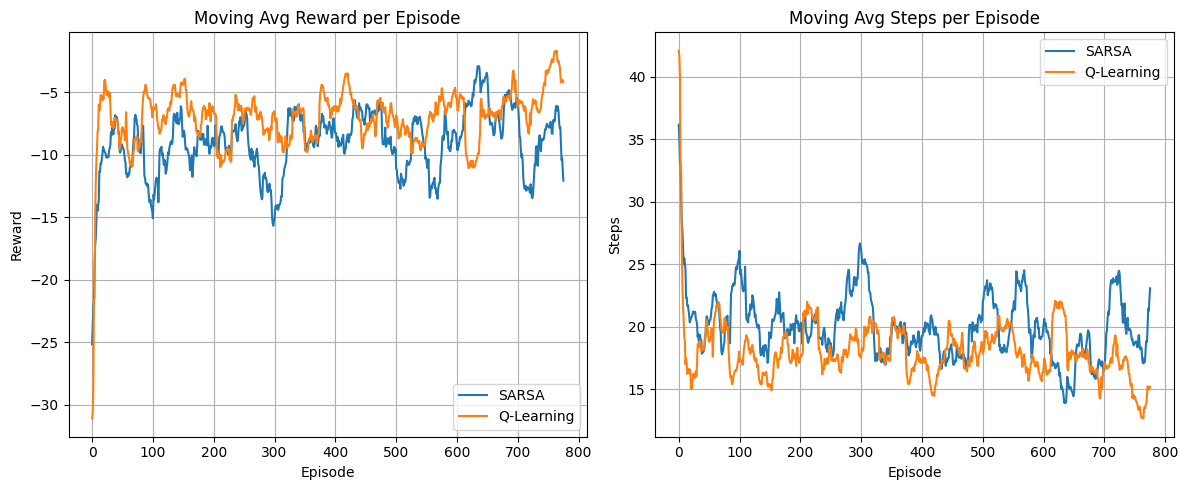

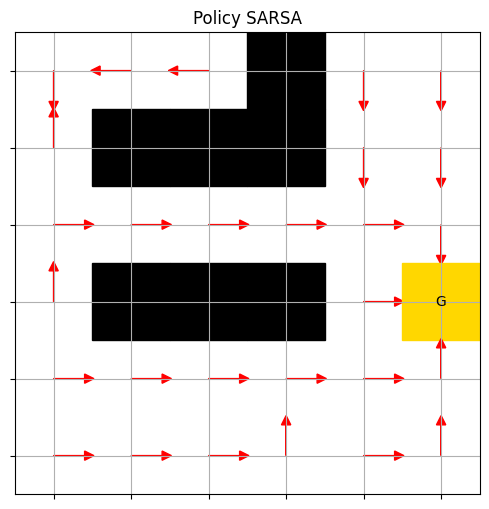

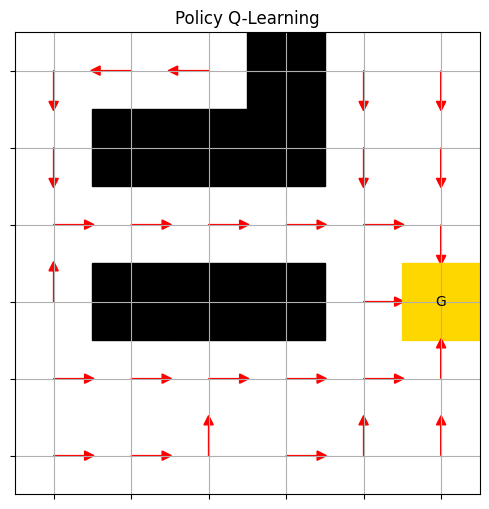

Summary:
SARSA: avg_reward(last100)=-9.69, avg_steps(last100)=20.7, best=3.0
Q-Learning: avg_reward(last100)=-4.83, avg_steps(last100)=15.8, best=3.0
Empirical winner (last-100 avg reward): Q-Learning


In [24]:
if __name__ == "__main__":
    main()